In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set(style='whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,roc_auc_score,auc)
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.svm import SVC
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"D:\Imarticus\ML\personal_carbon_footprint_behavior.csv")
df

,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level
0,1,Weekend,EV,1.55,6.12,0,Non-Veg,2.4,0.70,1,11.03,High
1,1,Weekend,Walk,10.04,4.50,0,Mixed,4.1,0.54,1,7.44,Medium
2,1,Weekday,Walk,15.27,2.81,0,Mixed,4.0,0.51,1,6.01,Medium
3,1,Weekend,Walk,0.50,10.16,0,Mixed,6.3,0.73,0,12.70,High
4,1,Weekend,Walk,3.60,5.02,50,Mixed,5.1,0.64,0,6.33,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...
1395,200,Weekend,Bike,7.73,4.12,25,Veg,2.8,0.58,1,4.83,Low
1396,200,Weekend,Walk,5.20,4.72,75,Non-Veg,7.1,0.56,1,6.74,Medium
1397,200,Weekday,Bike,7.16,3.88,25,Non-Veg,3.2,0.72,2,7.95,Medium
1398,200,Weekday,Bus,10.91,3.84,75,Mixed,4.7,0.77,0,6.08,Medium


In [3]:
df.head()

,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level
0,1,Weekend,EV,1.55,6.12,0,Non-Veg,2.4,0.70,1,11.03,High
1,1,Weekend,Walk,10.04,4.50,0,Mixed,4.1,0.54,1,7.44,Medium
2,1,Weekday,Walk,15.27,2.81,0,Mixed,4.0,0.51,1,6.01,Medium
3,1,Weekend,Walk,0.50,10.16,0,Mixed,6.3,0.73,0,12.70,High
4,1,Weekend,Walk,3.60,5.02,50,Mixed,5.1,0.64,0,6.33,Medium


In [4]:
df.tail()

,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level
1395,200,Weekend,Bike,7.73,4.12,25,Veg,2.8,0.58,1,4.83,Low
1396,200,Weekend,Walk,5.20,4.72,75,Non-Veg,7.1,0.56,1,6.74,Medium
1397,200,Weekday,Bike,7.16,3.88,25,Non-Veg,3.2,0.72,2,7.95,Medium
1398,200,Weekday,Bus,10.91,3.84,75,Mixed,4.7,0.77,0,6.08,Medium
1399,200,Weekend,EV,7.69,5.34,50,Non-Veg,5.0,0.81,1,8.57,Medium


In [5]:
df.sample()

,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level
586,84,Weekday,Bus,3.7,6.63,0,Non-Veg,8.7,0.76,0,12.15,High


In [6]:
df.shape

(1400, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              1400 non-null   int64  
 1   day_type             1400 non-null   object 
 2   transport_mode       1400 non-null   object 
 3   distance_km          1400 non-null   float64
 4   electricity_kwh      1400 non-null   float64
 5   renewable_usage_pct  1400 non-null   int64  
 6   food_type            1400 non-null   object 
 7   screen_time_hours    1400 non-null   float64
 8   waste_generated_kg   1400 non-null   float64
 9   eco_actions          1400 non-null   int64  
 10  carbon_footprint_kg  1400 non-null   float64
 11  carbon_impact_level  1400 non-null   object 
dtypes: float64(5), int64(3), object(4)
memory usage: 131.4+ KB


In [10]:
df.describe()

,user_id,distance_km,electricity_kwh,renewable_usage_pct,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg
count,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000
mean,100.500000,9.106071,5.951443,31.589286,5.521786,0.703200,1.144286,7.980236
std,57.754936,4.734692,1.993266,30.598496,2.018918,0.236415,1.019066,2.657858
min,1.000000,0.500000,2.000000,0.000000,2.000000,0.100000,0.000000,1.790000
25%,50.750000,5.662500,4.530000,0.000000,3.800000,0.550000,0.000000,6.080000
50%,100.500000,9.180000,5.925000,25.000000,5.550000,0.705000,1.000000,7.835000
75%,150.250000,12.510000,7.290000,50.000000,7.300000,0.860000,2.000000,9.830000
max,200.000000,22.670000,12.270000,100.000000,9.000000,1.510000,5.000000,16.020000


In [11]:
df.describe(include = "all")

,user_id,day_type,transport_mode,distance_km,electricity_kwh,renewable_usage_pct,food_type,screen_time_hours,waste_generated_kg,eco_actions,carbon_footprint_kg,carbon_impact_level
count,1400.000000,1400,1400,1400.000000,1400.000000,1400.000000,1400,1400.000000,1400.000000,1400.000000,1400.000000,1400
unique,NaN,2,5,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,3
top,NaN,Weekday,Bike,NaN,NaN,NaN,Non-Veg,NaN,NaN,NaN,NaN,Medium
freq,NaN,721,291,NaN,NaN,NaN,474,NaN,NaN,NaN,NaN,869
mean,100.500000,NaN,NaN,9.106071,5.951443,31.589286,NaN,5.521786,0.703200,1.144286,7.980236,NaN
std,57.754936,NaN,NaN,4.734692,1.993266,30.598496,NaN,2.018918,0.236415,1.019066,2.657858,NaN
min,1.000000,NaN,NaN,0.500000,2.000000,0.000000,NaN,2.000000,0.100000,0.000000,1.790000,NaN
25%,50.750000,NaN,NaN,5.662500,4.530000,0.000000,NaN,3.800000,0.550000,0.000000,6.080000,NaN
50%,100.500000,NaN,NaN,9.180000,5.925000,25.000000,NaN,5.550000,0.705000,1.000000,7.835000,NaN
75%,150.250000,NaN,NaN,12.510000,7.290000,50.000000,NaN,7.300000,0.860000,2.000000,9.830000,NaN


In [12]:
df.dtypes

user_id                  int64
day_type                object
transport_mode          object
distance_km            float64
electricity_kwh        float64
renewable_usage_pct      int64
food_type               object
screen_time_hours      float64
waste_generated_kg     float64
eco_actions              int64
carbon_footprint_kg    float64
carbon_impact_level     object
dtype: object

In [13]:
df.columns

Index(['user_id', 'day_type', 'transport_mode', 'distance_km',
       'electricity_kwh', 'renewable_usage_pct', 'food_type',
       'screen_time_hours', 'waste_generated_kg', 'eco_actions',
       'carbon_footprint_kg', 'carbon_impact_level'],
      dtype='object')

In [14]:
df.isnull().sum()

user_id                0
day_type               0
transport_mode         0
distance_km            0
electricity_kwh        0
renewable_usage_pct    0
food_type              0
screen_time_hours      0
waste_generated_kg     0
eco_actions            0
carbon_footprint_kg    0
carbon_impact_level    0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.nunique()

user_id                200
day_type                 2
transport_mode           5
distance_km            933
electricity_kwh        632
renewable_usage_pct      5
food_type                3
screen_time_hours       71
waste_generated_kg     125
eco_actions              6
carbon_footprint_kg    765
carbon_impact_level      3
dtype: int64

In [17]:
categorical = df.select_dtypes(include = 'object').columns

In [18]:
categorical

Index(['day_type', 'transport_mode', 'food_type', 'carbon_impact_level'], dtype='object')

In [19]:
numeric= df.select_dtypes(include="number")

for col in numeric:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outliers= outliers.shape[0]
    print(f"{col}:{outliers} ")

user_id:0 
distance_km:0 
electricity_kwh:4 
renewable_usage_pct:0 
screen_time_hours:0 
waste_generated_kg:3 
eco_actions:0 
carbon_footprint_kg:3 


In [20]:
df['carbon_impact_level'].value_counts()

carbon_impact_level
Medium    869
Low       337
High      194
Name: count, dtype: int64

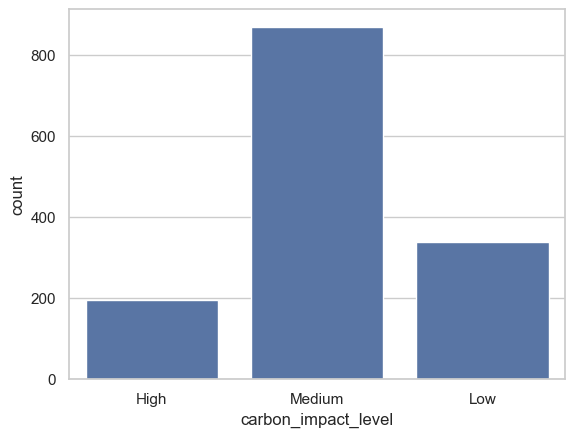

In [21]:
sns.countplot(x='carbon_impact_level',data = df)
plt.show()

In [22]:
label = LabelEncoder()
cat_cols = categorical
for col in cat_cols:
    df[col] = df[col].astype(str)
    df[col] = label.fit_transform(df[col])

In [23]:
x = df.drop(columns=['carbon_impact_level'])
y = df[['carbon_impact_level']]

In [24]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [25]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.2,random_state=42)

In [26]:
svm = SVC()
svm.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [27]:
y_pred = svm.predict(x_test)

In [28]:
print("accuracy =", accuracy_score(y_test,y_pred))

accuracy = 0.675


In [29]:
print("Training Accuracy",svm.score(x_train,y_train))
print("Testing Accuracy",svm.score(x_test,y_test))

Training Accuracy 0.7116071428571429
Testing Accuracy 0.675
